In [7]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import json

# Define the project root
project_root = Path("..").resolve().parent

# Add the project root to sys.path so Jupyter can find your 'src' module
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Load data/valencia_cf_1/matches.json into a dataframe called matches_df
matches_path = project_root / "data" / "valencia_cf_1" / "matches.json"

In [8]:
RANDOM_SEED = 42

# Calibration set = match_id <= this value (these matches fed the PCA weights /
# Bayesian smoothing means & stds). Anything above this id is held-out and never
# touched calibration.
CALIBRATION_MAX_MATCH_ID = 106

# Spearman test parameters
ALPHA = 0.05
ALTERNATIVE = "greater"  # H1: rho > 0 (positive monotonic relationship between
                         # team-average rating and goal difference)
N_BOOTSTRAP_RESAMPLES = 5000

# Effect-size bands for |rho|, pre-registered before seeing results
EFFECT_SIZE_BANDS = {
    "negligible": (0.00, 0.10),
    "weak":       (0.10, 0.30),
    "moderate":   (0.30, 0.50),
    "strong":     (0.50, 1.01),  # padded past 1.0 so the top band is inclusive
}

def classify_effect_size(rho: float) -> str:
    """Label |rho| against the pre-registered effect-size bands."""
    abs_rho = abs(rho)
    return next(
        (
            label
            for label, (lo, hi) in EFFECT_SIZE_BANDS.items()
            if lo <= abs_rho < hi
        ),
        "strong",
    )

In [9]:
with open(matches_path, "r") as f:
    data = json.load(f)

players_df = pd.json_normalize(
    data,
    record_path='player_performances',
    meta=['id']
)

players_df = players_df.rename(columns={'id': 'match_id'})

cols = ['match_id'] + [col for col in players_df.columns if col != 'match_id']
players_df = players_df[cols]

In [10]:
team_df = pd.json_normalize(data)

is_valencia_home = team_df['data.home_team_name'] == "Valencia CF"

team_df['val_goals_for'] = np.where(is_valencia_home, team_df['data.home_score'], team_df['data.away_score'])
team_df['val_goals_against'] = np.where(is_valencia_home, team_df['data.away_score'], team_df['data.home_score'])

team_df['val_xg_for'] = np.where(is_valencia_home, team_df['data.home_stats.xg'], team_df['data.away_stats.xg'])
team_df['val_xg_against'] = np.where(is_valencia_home, team_df['data.away_stats.xg'], team_df['data.home_stats.xg'])

team_df['goal_difference'] = team_df['val_goals_for'] - team_df['val_goals_against']

final_columns = [
    'id', 
    'data.in_game_date', 
    'data.competition',
    'data.home_team_name', 
    'data.away_team_name',
    'val_goals_for', 
    'val_goals_against', 
    'goal_difference',
    'val_xg_for', 
    'val_xg_against'
]

team_df = team_df[final_columns].rename(columns={
    'id': 'match_id',
    'data.in_game_date': 'date',
    'data.competition': 'competition',
    'data.home_team_name': 'home_team',
    'data.away_team_name': 'away_team'
})

In [11]:
# All performances (GK + outfield) - the version originally used.
match_averages_df = players_df.groupby('match_id')['match_rating'].mean().reset_index()

match_averages_df = match_averages_df.rename(columns={'match_rating': 'avg_match_rating'})

In [12]:
# Outfield-only - robustness comparison against the all-performances version above.
# Goalkeeper ratings run through separate heuristics (06c), so it's worth checking
# whether including them changes the construct-validity result rather than assuming
# either way by default.
match_averages_outfield_df = (
    players_df[players_df['performance_type'] == 'Outfield']
    .groupby('match_id')['match_rating']
    .mean()
    .reset_index()
    .rename(columns={'match_rating': 'avg_match_rating'})
)

In [13]:
team_averages_df = pd.merge(
    match_averages_df,
    team_df[['match_id', 'goal_difference']], 
    on='match_id',
    how='inner'
)

team_averages_df = team_averages_df.rename(columns={
    'avg_match_rating': 'avg_match_rating',
    'goal_difference': 'goal_diff'
})

In [14]:
team_averages_outfield_df = pd.merge(
    match_averages_outfield_df,
    team_df[['match_id', 'goal_difference']],
    on='match_id',
    how='inner'
).rename(columns={'goal_difference': 'goal_diff'})

In [15]:
calibration_set = team_averages_df[team_averages_df['match_id'] <= CALIBRATION_MAX_MATCH_ID].copy()
validation_set = team_averages_df[team_averages_df['match_id'] > CALIBRATION_MAX_MATCH_ID].copy()

calibration_set_outfield = team_averages_outfield_df[team_averages_outfield_df['match_id'] <= CALIBRATION_MAX_MATCH_ID].copy()
validation_set_outfield = team_averages_outfield_df[team_averages_outfield_df['match_id'] > CALIBRATION_MAX_MATCH_ID].copy()

In [16]:
# 1. Wrapper function for the bootstrap statistic
def spearman_statistic(x, y):
    return stats.spearmanr(x, y)[0]

# 2. Helper function to compute stats for any given dataset split
def analyze_split(df, rating_col='avg_match_rating', gd_col='goal_diff'):
    ratings = df[rating_col].values
    gds = df[gd_col].values
    
    # Pre-registered one-tailed test: H1 is rho > 0, not rho != 0
    rho, p_val = stats.spearmanr(ratings, gds, alternative=ALTERNATIVE)
    
    # Bootstrap CI on rho
    boot_res = stats.bootstrap(
        data=(ratings, gds),
        statistic=spearman_statistic,
        paired=True,
        vectorized=False,
        n_resamples=N_BOOTSTRAP_RESAMPLES,
        method='percentile',
        random_state=RANDOM_SEED
    )
    
    return rho, p_val, boot_res.confidence_interval.low, boot_res.confidence_interval.high, boot_res.standard_error

# 3. Run on all four splits: all-performances vs outfield-only, validation vs calibration
val_rho, val_p, val_ci_l, val_ci_h, val_se = analyze_split(validation_set)
cal_rho, cal_p, cal_ci_l, cal_ci_h, cal_se = analyze_split(calibration_set)
val_of_rho, val_of_p, val_of_ci_l, val_of_ci_h, val_of_se = analyze_split(validation_set_outfield)
cal_of_rho, cal_of_p, cal_of_ci_l, cal_of_ci_h, cal_of_se = analyze_split(calibration_set_outfield)

def print_comparison(label, v_rho, v_p, v_ci_l, v_ci_h, v_se, c_rho, c_p, c_ci_l, c_ci_h, c_se):
    print(label)
    print(
        f"{'Metric':<25} | {f'Validation (id > {str(CALIBRATION_MAX_MATCH_ID)})':<25} | Calibration (id <= {CALIBRATION_MAX_MATCH_ID})"
    )
    print("-" * 85)
    print(f"{'Spearman rho (ρ)':<25} | {v_rho:<25.3f} | {c_rho:.3f}")
    print(f"{'p-value':<25} | {v_p:<25.4f} | {c_p:.4f}")
    print(f"{'95% CI':<25} | [{v_ci_l:.3f}, {v_ci_h:.3f}]{'':<10} | [{c_ci_l:.3f}, {c_ci_h:.3f}]")
    print(f"{'Standard Error':<25} | {v_se:<25.4f} | {c_se:.4f}")
    print(f"{'Effect size':<25} | {classify_effect_size(v_rho):<25} | {classify_effect_size(c_rho)}")
    print(
        f"{f'Significant (α={str(ALPHA)})':<25} | {str(v_p < ALPHA):<25} | {c_p < ALPHA}"
    )
    print()

print_comparison("ALL PERFORMANCES (GK + outfield)",
                  val_rho, val_p, val_ci_l, val_ci_h, val_se,
                  cal_rho, cal_p, cal_ci_l, cal_ci_h, cal_se)

print_comparison("OUTFIELD ONLY (GK excluded)",
                  val_of_rho, val_of_p, val_of_ci_l, val_of_ci_h, val_of_se,
                  cal_of_rho, cal_of_p, cal_of_ci_l, cal_of_ci_h, cal_of_se)

print(f"Δρ (all - outfield): validation = {val_rho - val_of_rho:+.3f}, calibration = {cal_rho - cal_of_rho:+.3f}")

ALL PERFORMANCES (GK + outfield)
Metric                    | Validation (id > 106)     | Calibration (id <= 106)
-------------------------------------------------------------------------------------
Spearman rho (ρ)          | 0.826                     | 0.830
p-value                   | 0.0000                    | 0.0000
95% CI                    | [0.670, 0.917]           | [0.747, 0.887]
Standard Error            | 0.0635                    | 0.0362
Effect size               | strong                    | strong
Significant (α=0.05)      | True                      | True

OUTFIELD ONLY (GK excluded)
Metric                    | Validation (id > 106)     | Calibration (id <= 106)
-------------------------------------------------------------------------------------
Spearman rho (ρ)          | 0.823                     | 0.842
p-value                   | 0.0000                    | 0.0000
95% CI                    | [0.668, 0.912]           | [0.763, 0.898]
Standard Error            | 0

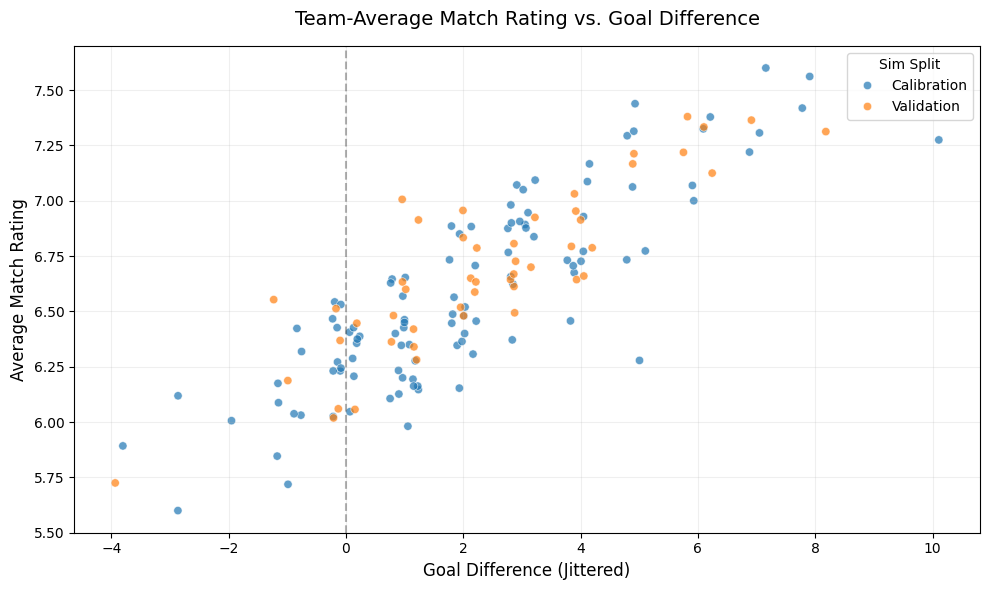

In [17]:
calibration_set['dataset'] = 'Calibration'
validation_set['dataset'] = 'Validation'
plot_df = pd.concat([calibration_set, validation_set])

# 2. Apply horizontal jitter to Goal Difference
np.random.seed(42) # Lock seed so the jitter doesn't dance around between runs
plot_df['gd_jittered'] = plot_df['goal_diff'] + np.random.uniform(-0.25, 0.25, size=len(plot_df))

# 3. Build the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df, 
    x='gd_jittered', 
    y='avg_match_rating', 
    hue='dataset',
    palette={'Calibration': '#1f77b4', 'Validation': '#ff7f0e'}, # Clean blue/orange split
    alpha=0.7, # Transparency to handle any remaining overlap
    edgecolor='w',
    linewidth=0.5
)

# 4. Formatting
plt.title("Team-Average Match Rating vs. Goal Difference", fontsize=14, pad=15)
plt.xlabel("Goal Difference (Jittered)", fontsize=12)
plt.ylabel("Average Match Rating", fontsize=12)
plt.axvline(0, color='black', linestyle='--', alpha=0.3) # Reference line for draws
plt.grid(True, alpha=0.2)
plt.legend(title='Sim Split')

plt.tight_layout()
plt.show()

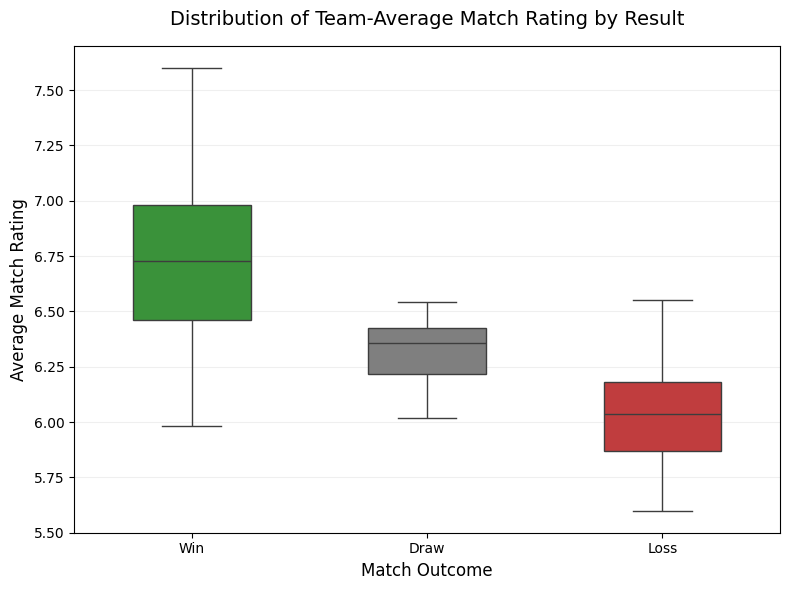

In [18]:
# 1. Derive W/D/L from Goal Difference
conditions = [
    (team_averages_df['goal_diff'] > 0),
    (team_averages_df['goal_diff'] == 0),
    (team_averages_df['goal_diff'] < 0)
]
choices = ['Win', 'Draw', 'Loss']

# Pass an explicit string default so NumPy maintains a uniform StrDType
team_averages_df['outcome'] = np.select(conditions, choices, default='Unknown')

# 2. Build the Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=team_averages_df,
    x='outcome',
    y='avg_match_rating',
    hue='outcome',
    order=['Win', 'Draw', 'Loss'], 
    palette={'Win': '#2ca02c', 'Draw': '#7f7f7f', 'Loss': '#d62728'},
    width=0.5,
    fliersize=4,
    legend=False
)

plt.title("Distribution of Team-Average Match Rating by Result", fontsize=14, pad=15)
plt.xlabel("Match Outcome", fontsize=12)
plt.ylabel("Average Match Rating", fontsize=12)
plt.grid(True, axis='y', alpha=0.2)

plt.tight_layout()
plt.show()